# Model Testing and Debugging

This notebook is for testing individual components of the neural network.

## Goals:
- Test activation functions
- Test loss functions
- Test forward propagation
- Test backward propagation
- Verify gradient computations
- Test optimizers


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.neural_network import NeuralNetwork
from src.activations import *
from src.losses import *
from src.optimizers import *
from src.initializers import *

%matplotlib inline


## 1. Test Activation Functions

We'll test each activation function and its derivative to ensure they work correctly.


ReLU Activation Function
Input range: [-5.00, 5.00]
Output range: [0.00, 5.00]
Derivative at x=0: 0.0
Derivative at x=2: 1.0
Derivative at x=-2: 0.0


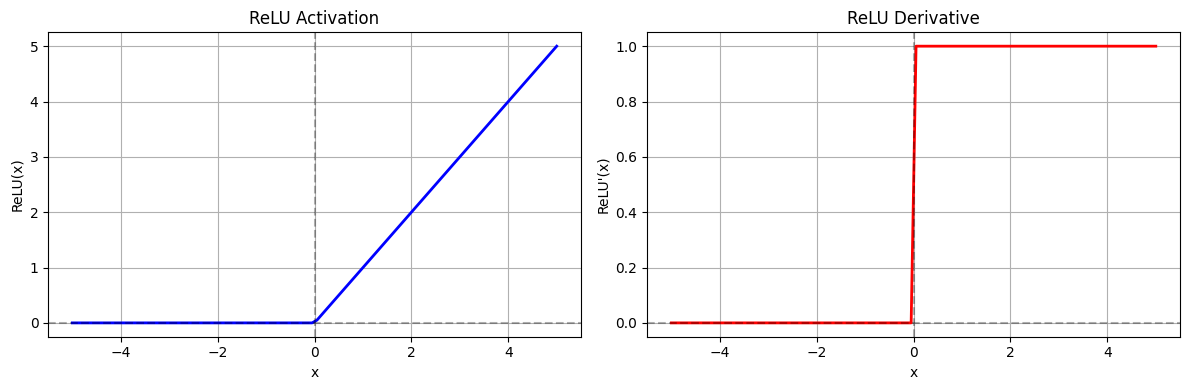

In [18]:
# Test Activation Functions

# Create test input
x = np.linspace(-5, 5, 100)

# Test ReLU
print("=" * 30)
print("ReLU Activation Function")
print("=" * 30)
relu_output = relu(x)
relu_deriv = relu_derivative(x)
print(f"Input range: [{x.min():.2f}, {x.max():.2f}]")
print(f"Output range: [{relu_output.min():.2f}, {relu_output.max():.2f}]")
print(f"Derivative at x=0: {relu_derivative(np.array([0.0]))[0]}")
print(f"Derivative at x=2: {relu_derivative(np.array([2.0]))[0]}")
print(f"Derivative at x=-2: {relu_derivative(np.array([-2.0]))[0]}")

# Plot ReLU
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, relu_output, 'b-', linewidth=2)
axes[0].set_title('ReLU Activation')
axes[0].set_xlabel('x')
axes[0].set_ylabel('ReLU(x)')
axes[0].grid(True)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)

axes[1].plot(x, relu_deriv, 'r-', linewidth=2)
axes[1].set_title('ReLU Derivative')
axes[1].set_xlabel('x')
axes[1].set_ylabel("ReLU'(x)")
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Sigmoid Activation Function
Input range: [-5.00, 5.00]
Output range: [0.0067, 0.9933]
Sigmoid(0) = 0.5000 (should be ~0.5)
Max derivative: 0.2498 (should be ~0.25 at x=0)


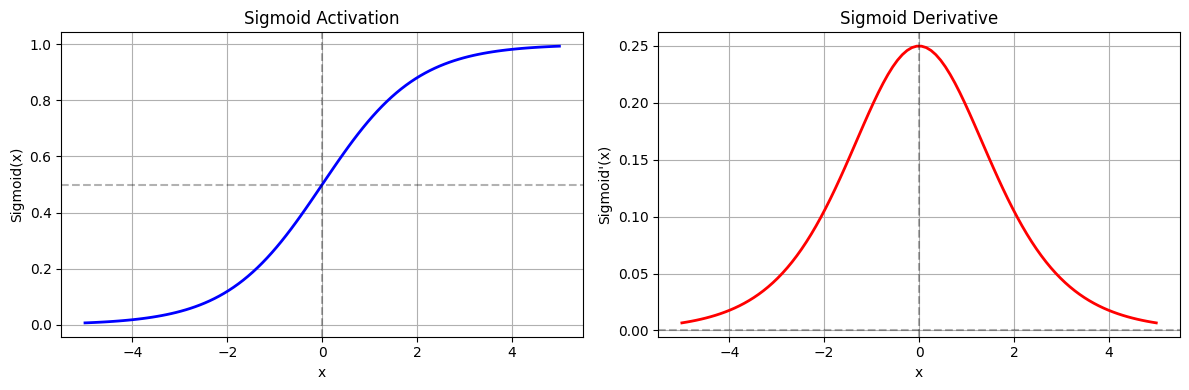

In [19]:
# Test Sigmoid
print("=" * 30)
print("Sigmoid Activation Function")
print("=" * 30)
sigmoid_output = sigmoid(x)
sigmoid_deriv = sigmoid_derivative(x)
print(f"Input range: [{x.min():.2f}, {x.max():.2f}]")
print(f"Output range: [{sigmoid_output.min():.4f}, {sigmoid_output.max():.4f}]")
print(f"Sigmoid(0) = {sigmoid(np.array([0.0]))[0]:.4f} (should be ~0.5)")
print(f"Max derivative: {sigmoid_deriv.max():.4f} (should be ~0.25 at x=0)")

# Plot Sigmoid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, sigmoid_output, 'b-', linewidth=2)
axes[0].set_title('Sigmoid Activation')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Sigmoid(x)')
axes[0].grid(True)
axes[0].axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)

axes[1].plot(x, sigmoid_deriv, 'r-', linewidth=2)
axes[1].set_title('Sigmoid Derivative')
axes[1].set_xlabel('x')
axes[1].set_ylabel("Sigmoid'(x)")
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Tanh Activation Function
Input range: [-5.00, 5.00]
Output range: [-0.9999, 0.9999]
Tanh(0) = 0.0000 (should be ~0.0)
Max derivative: 0.9975 (should be ~1.0 at x=0)


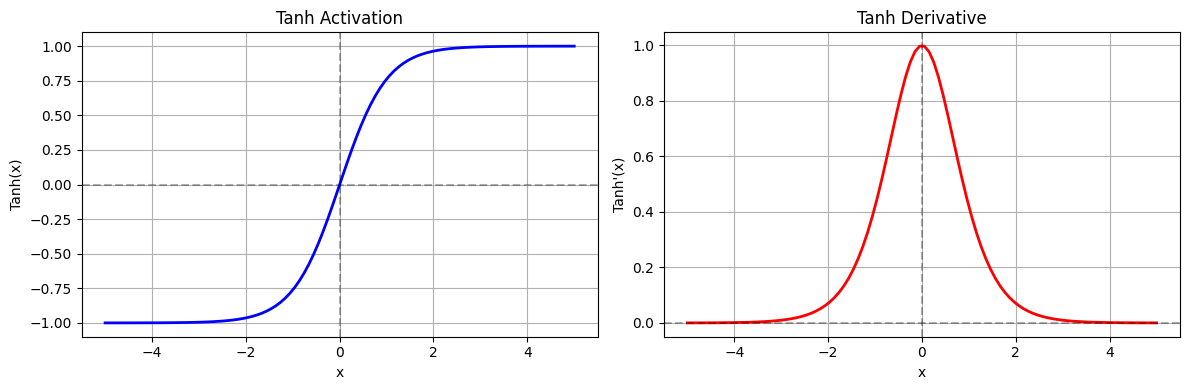

In [20]:
# Test Tanh
print("=" * 30)
print("Tanh Activation Function")
print("=" * 30)
tanh_output = tanh(x)
tanh_deriv = tanh_derivative(x)
print(f"Input range: [{x.min():.2f}, {x.max():.2f}]")
print(f"Output range: [{tanh_output.min():.4f}, {tanh_output.max():.4f}]")
print(f"Tanh(0) = {tanh(np.array([0.0]))[0]:.4f} (should be ~0.0)")
print(f"Max derivative: {tanh_deriv.max():.4f} (should be ~1.0 at x=0)")

# Plot Tanh
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, tanh_output, 'b-', linewidth=2)
axes[0].set_title('Tanh Activation')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Tanh(x)')
axes[0].grid(True)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)

axes[1].plot(x, tanh_deriv, 'r-', linewidth=2)
axes[1].set_title('Tanh Derivative')
axes[1].set_xlabel('x')
axes[1].set_ylabel("Tanh'(x)")
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Softmax Activation Function

Test 1: Input = [1. 2. 3.]
  Output = [0.09003057 0.24472847 0.66524096]
  Sum = 1.000000 (should be 1.0)
  Max index = 2 (input max at index 2)

Test 2: Input = [0. 0. 0.]
  Output = [0.33333333 0.33333333 0.33333333]
  Sum = 1.000000 (should be 1.0)
  Max index = 0 (input max at index 0)

Test 3: Input = [100. 101. 102.]
  Output = [0.09003057 0.24472847 0.66524096]
  Sum = 1.000000 (should be 1.0)
  Max index = 2 (input max at index 2)

Test 4: Input = [1. 5. 2.]
  Output = [0.01714783 0.93623955 0.04661262]
  Sum = 1.000000 (should be 1.0)
  Max index = 1 (input max at index 1)


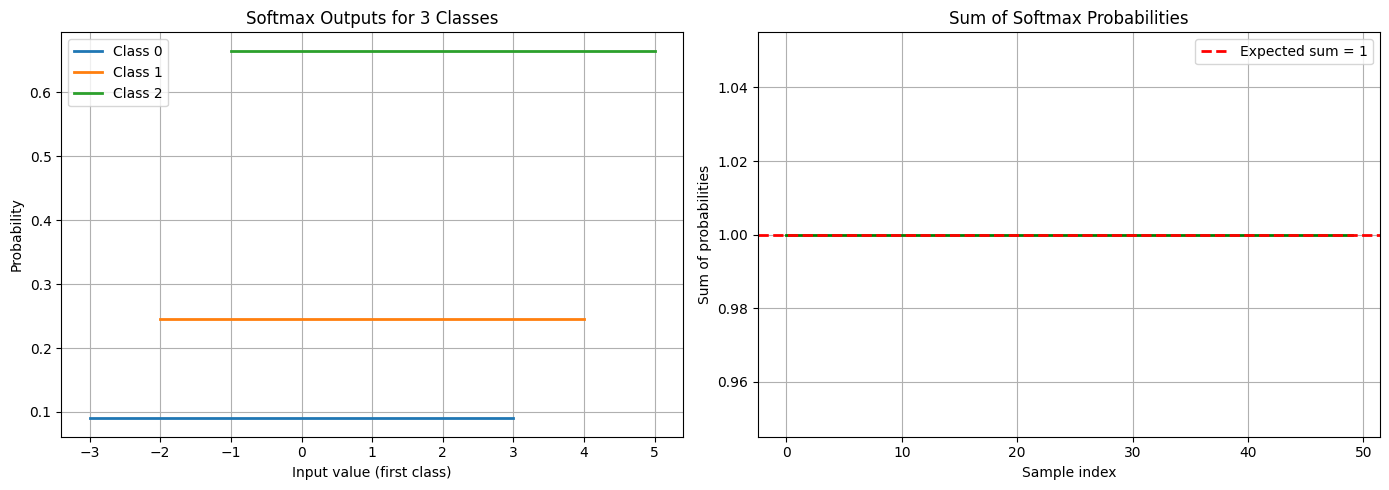

In [21]:
# Test Softmax
print("=" * 30)
print("Softmax Activation Function")
print("=" * 30)

# Test with different inputs
test_inputs = [
    np.array([[1.0, 2.0, 3.0]]),
    np.array([[0.0, 0.0, 0.0]]),
    np.array([[100.0, 101.0, 102.0]]),  # Test numerical stability
    np.array([[1.0, 5.0, 2.0]])
]

for i, test_input in enumerate(test_inputs):
    softmax_output = softmax(test_input)
    print(f"\nTest {i+1}: Input = {test_input[0]}")
    print(f"  Output = {softmax_output[0]}")
    print(f"  Sum = {softmax_output[0].sum():.6f} (should be 1.0)")
    print(f"  Max index = {np.argmax(softmax_output[0])} (input max at index {np.argmax(test_input[0])})")

# Visualize softmax for a range of inputs
x_softmax = np.array([[i, i+1, i+2] for i in np.linspace(-3, 3, 50)])
softmax_outputs = softmax(x_softmax)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(3):
    axes[0].plot(x_softmax[:, i], softmax_outputs[:, i], label=f'Class {i}', linewidth=2)
axes[0].set_title('Softmax Outputs for 3 Classes')
axes[0].set_xlabel('Input value (first class)')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].grid(True)

# Show that probabilities sum to 1
sums = np.sum(softmax_outputs, axis=1)
axes[1].plot(sums, 'g-', linewidth=2)
axes[1].axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Expected sum = 1')
axes[1].set_title('Sum of Softmax Probabilities')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Sum of probabilities')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


Comparison of Activation Functions


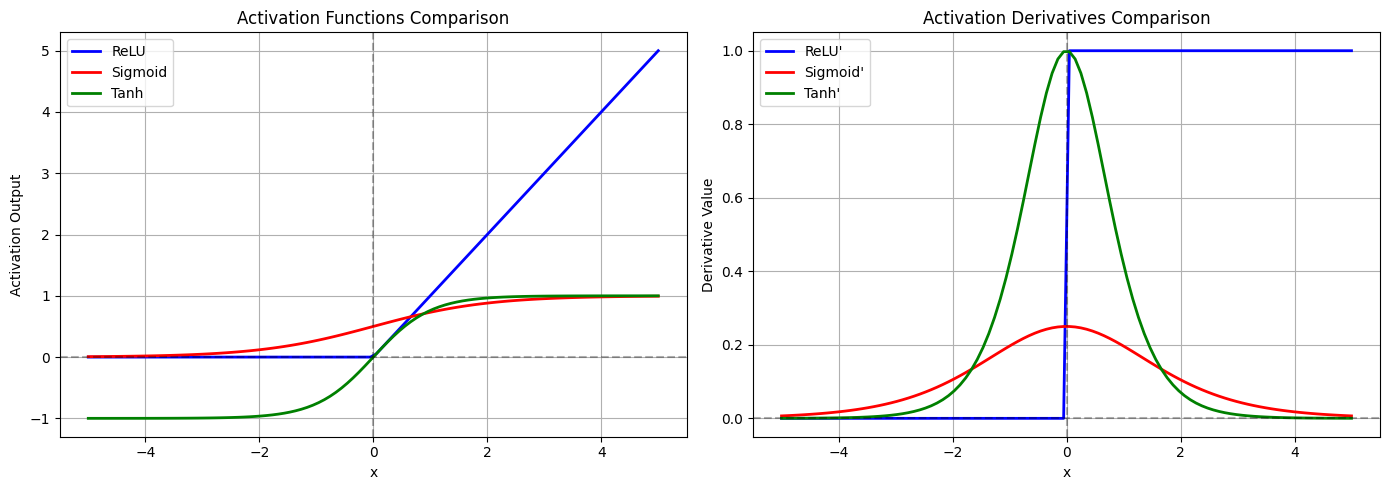


Key Properties:
- ReLU: Linear for x > 0, zero otherwise. Derivative is 1 for x > 0, 0 otherwise.
- Sigmoid: Output range [0, 1]. Derivative peaks at 0.25 when x = 0.
- Tanh: Output range [-1, 1]. Derivative peaks at 1.0 when x = 0.
- Softmax: Converts logits to probability distribution (sums to 1).


In [22]:
# Compare all activation functions
print("=" * 30)
print("Comparison of Activation Functions")
print("=" * 30)

x_compare = np.linspace(-5, 5, 100)
relu_vals = relu(x_compare)
sigmoid_vals = sigmoid(x_compare)
tanh_vals = tanh(x_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot activations
axes[0].plot(x_compare, relu_vals, 'b-', label='ReLU', linewidth=2)
axes[0].plot(x_compare, sigmoid_vals, 'r-', label='Sigmoid', linewidth=2)
axes[0].plot(x_compare, tanh_vals, 'g-', label='Tanh', linewidth=2)
axes[0].set_title('Activation Functions Comparison')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Activation Output')
axes[0].legend()
axes[0].grid(True)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Plot derivatives
relu_deriv_vals = relu_derivative(x_compare)
sigmoid_deriv_vals = sigmoid_derivative(x_compare)
tanh_deriv_vals = tanh_derivative(x_compare)

axes[1].plot(x_compare, relu_deriv_vals, 'b-', label="ReLU'", linewidth=2)
axes[1].plot(x_compare, sigmoid_deriv_vals, 'r-', label="Sigmoid'", linewidth=2)
axes[1].plot(x_compare, tanh_deriv_vals, 'g-', label="Tanh'", linewidth=2)
axes[1].set_title('Activation Derivatives Comparison')
axes[1].set_xlabel('x')
axes[1].set_ylabel("Derivative Value")
axes[1].legend()
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Properties:")
print("- ReLU: Linear for x > 0, zero otherwise. Derivative is 1 for x > 0, 0 otherwise.")
print("- Sigmoid: Output range [0, 1]. Derivative peaks at 0.25 when x = 0.")
print("- Tanh: Output range [-1, 1]. Derivative peaks at 1.0 when x = 0.")
print("- Softmax: Converts logits to probability distribution (sums to 1).")


In [23]:
# Test numerical stability and edge cases
print("=" * 30)
print("Numerical Stability Tests")
print("=" * 30)

# Test sigmoid with extreme values
extreme_values = np.array([-1000, -100, -10, 0, 10, 100, 1000])
print("\nSigmoid with extreme values:")
for val in extreme_values:
    result = sigmoid(np.array([val]))[0]
    print(f"  sigmoid({val:6.0f}) = {result:.6f}")

# Test softmax with extreme values
print("\nSoftmax with extreme values:")
extreme_softmax = np.array([[1000, 1001, 1002]])
result = softmax(extreme_softmax)
print(f"  Input: {extreme_softmax[0]}")
print(f"  Output: {result[0]}")
print(f"  Sum: {result[0].sum():.10f}")
print(f"  All finite: {np.isfinite(result).all()}")

# Test ReLU with zeros
print("\nReLU edge cases:")
print(f"  ReLU(0) = {relu(np.array([0.0]))[0]}")
print(f"  ReLU(-0) = {relu(np.array([-0.0]))[0]}")
print(f"  ReLU derivative at 0 = {relu_derivative(np.array([0.0]))[0]}")


Numerical Stability Tests

Sigmoid with extreme values:
  sigmoid( -1000) = 0.000000
  sigmoid(  -100) = 0.000000
  sigmoid(   -10) = 0.000045
  sigmoid(     0) = 0.500000
  sigmoid(    10) = 0.999955
  sigmoid(   100) = 1.000000
  sigmoid(  1000) = 1.000000

Softmax with extreme values:
  Input: [1000 1001 1002]
  Output: [0.09003057 0.24472847 0.66524096]
  Sum: 1.0000000000
  All finite: True

ReLU edge cases:
  ReLU(0) = 0.0
  ReLU(-0) = 0.0
  ReLU derivative at 0 = 0.0


## 2. Test Optimizers

We'll test the SGD optimizer on simple functions to verify it works correctly.


In [24]:
# Test SGD Optimizer on Simple Functions

print("=" * 60)
print("SGD Optimizer Tests")
print("=" * 60)

# Test 1: Minimize a simple quadratic function
# f(x) = (x - 5)^2, minimum at x = 5
print("\nTest 1: Minimizing f(x) = (x - 5)^2")
print("-" * 60)

optimizer = SGD(learning_rate=0.1)
params = {'x': np.array([0.0])}  # Start at x = 0
initial_x = params['x'][0]

history = [initial_x]

for step in range(50):
    x_val = params['x'][0]
    # Gradient: df/dx = 2*(x - 5)
    grads = {'x': np.array([2 * (x_val - 5)])}
    params = optimizer.update(params, grads)
    history.append(params['x'][0])
    
    if step % 10 == 0:
        print(f"Step {step:3d}: x = {x_val:.4f}, gradient = {grads['x'][0]:.4f}")

final_x = params['x'][0]
print(f"\nFinal: x = {final_x:.4f} (target: 5.0)")
print(f"Error: {abs(final_x - 5.0):.6f}")

# Plot convergence
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history, 'b-', linewidth=2, marker='o', markersize=4)
plt.axhline(y=5.0, color='r', linestyle='--', linewidth=2, label='Target (x=5)')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('SGD: Minimizing f(x) = (x-5)²')
plt.legend()
plt.grid(True)

# Plot function and path
x_range = np.linspace(-1, 11, 100)
y_range = (x_range - 5)**2
plt.subplot(1, 2, 2)
plt.plot(x_range, y_range, 'b-', linewidth=2, label='f(x) = (x-5)²')
plt.plot(history, [(x-5)**2 for x in history], 'ro-', markersize=6, label='Optimization path')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and Optimization Path')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


SGD Optimizer Tests

Test 1: Minimizing f(x) = (x - 5)^2
------------------------------------------------------------


TypeError: 'NoneType' object is not subscriptable

In [25]:
# Test 2: Minimize a 2D function
# f(x, y) = x² + y², minimum at (0, 0)
print("\nTest 2: Minimizing f(x, y) = x² + y²")
print("-" * 60)

optimizer = SGD(learning_rate=0.1)
params = {
    'x': np.array([3.0]),
    'y': np.array([4.0])
}

initial_x, initial_y = params['x'][0], params['y'][0]
print(f"Starting point: ({initial_x}, {initial_y})")
print(f"Initial function value: {initial_x**2 + initial_y**2:.4f}")

x_history = [initial_x]
y_history = [initial_y]
loss_history = [initial_x**2 + initial_y**2]

for step in range(50):
    x_val = params['x'][0]
    y_val = params['y'][0]
    
    # Gradients: df/dx = 2x, df/dy = 2y
    grads = {
        'x': np.array([2 * x_val]),
        'y': np.array([2 * y_val])
    }
    
    params = optimizer.update(params, grads)
    x_history.append(params['x'][0])
    y_history.append(params['y'][0])
    loss_history.append(params['x'][0]**2 + params['y'][0]**2)
    
    if step % 10 == 0:
        print(f"Step {step:3d}: x = {params['x'][0]:.4f}, y = {params['y'][0]:.4f}, "
              f"loss = {loss_history[-1]:.6f}")

final_x, final_y = params['x'][0], params['y'][0]
final_loss = final_x**2 + final_y**2
print(f"\nFinal point: ({final_x:.4f}, {final_y:.4f})")
print(f"Final loss: {final_loss:.6f} (target: 0.0)")
print(f"Distance from origin: {np.sqrt(final_x**2 + final_y**2):.6f}")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot parameter values
axes[0].plot(x_history, 'b-', linewidth=2, label='x', marker='o', markersize=4)
axes[0].plot(y_history, 'r-', linewidth=2, label='y', marker='s', markersize=4)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Parameter value')
axes[0].set_title('SGD: Parameter Convergence')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(loss_history, 'g-', linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss (x² + y²)')
axes[1].set_title('SGD: Loss Convergence')
axes[1].set_yscale('log')
axes[1].grid(True)
plt.tight_layout()
plt.show()



Test 2: Minimizing f(x, y) = x² + y²
------------------------------------------------------------
Starting point: (3.0, 4.0)
Initial function value: 25.0000


TypeError: 'NoneType' object is not subscriptable


Test 3: Effect of Learning Rate
------------------------------------------------------------


TypeError: 'NoneType' object is not subscriptable

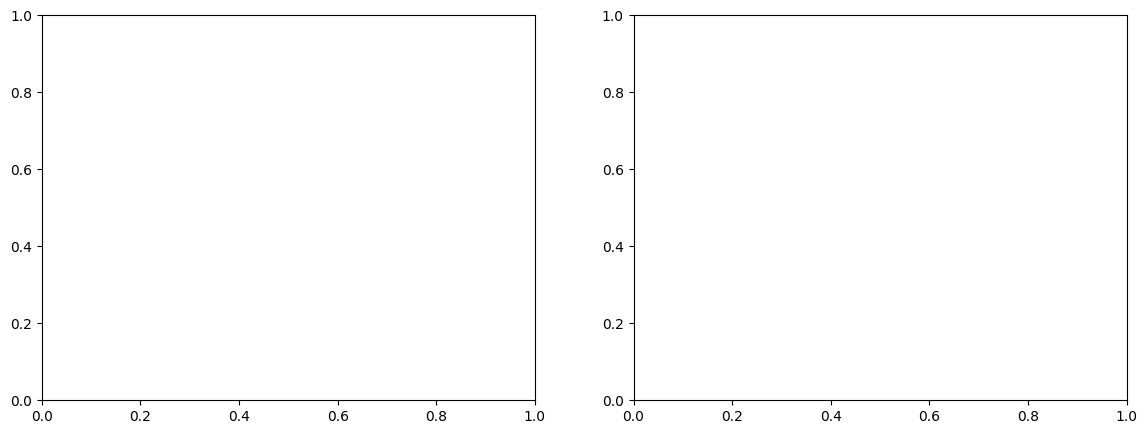

In [26]:
# Test 3: Compare different learning rates
print("\nTest 3: Effect of Learning Rate")
print("-" * 60)

learning_rates = [0.01, 0.1, 0.5]
colors = ['b', 'r', 'g']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, color in zip(learning_rates, colors):
    optimizer = SGD(learning_rate=lr)
    params = {'x': np.array([10.0])}  # Start far from minimum
    history = [params['x'][0]]
    
    for step in range(30):
        x_val = params['x'][0]
        grads = {'x': np.array([2 * (x_val - 5)])}  # f(x) = (x-5)^2
        params = optimizer.update(params, grads)
        history.append(params['x'][0])
    
    axes[0].plot(history, color=color, linewidth=2, label=f'LR={lr}', marker='o', markersize=3)
    axes[1].plot([abs(x - 5) for x in history], color=color, linewidth=2, label=f'LR={lr}', marker='o', markersize=3)

axes[0].axhline(y=5.0, color='k', linestyle='--', alpha=0.3, label='Target')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('x value')
axes[0].set_title('Convergence with Different Learning Rates')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('|x - 5| (error)')
axes[1].set_title('Error Convergence')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Smaller learning rates converge more slowly but more stably")
print("- Larger learning rates converge faster but may overshoot")
print("- Learning rate 0.1 provides a good balance for this function")


In [ ]:
# Test 4: SGD with neural network-like parameters
print("\nTest 4: SGD with Multiple Parameters (Neural Network Style)")
print("-" * 60)

optimizer = SGD(learning_rate=0.01)

# Simulate a small neural network: 2 inputs -> 3 hidden -> 2 outputs
params = {
    'W1': np.random.randn(2, 3) * 0.1,  # Input to hidden weights
    'b1': np.zeros(3),                  # Hidden biases
    'W2': np.random.randn(3, 2) * 0.1,  # Hidden to output weights
    'b2': np.zeros(2)                    # Output biases
}

# Simulate gradients (normally computed via backprop)
grads = {
    'W1': np.random.randn(2, 3) * 0.01,
    'b1': np.random.randn(3) * 0.01,
    'W2': np.random.randn(3, 2) * 0.01,
    'b2': np.random.randn(2) * 0.01
}

print("Initial parameters:")
for key, value in params.items():
    print(f"  {key}: shape {value.shape}, mean = {value.mean():.4f}, std = {value.std():.4f}")

# Store initial values for comparison
initial_params = {k: v.copy() for k, v in params.items()}

# Perform update
updated_params = optimizer.update(params, grads)

print("\nAfter SGD update:")
for key in params.keys():
    diff = updated_params[key] - initial_params[key]
    expected_diff = -optimizer.learning_rate * grads[key]
    print(f"  {key}:")
    print(f"    Change magnitude: {np.abs(diff).mean():.6f}")
    print(f"    Matches expected: {np.allclose(diff, expected_diff)}")

print("\n✓ SGD correctly updates all parameters!")
print("✓ Update rule: param_new = param_old - learning_rate * gradient")
